# Lab 03 – Geometric Transformations (Linear → Affine → Projective)
Run the cells top to bottom. The **setup** and **sample-data** cells create everything the tasks need (matrix builders, helper functions and one synthetic image per task), so no uploads are required.

To use your own images, put them in `lab03_samples/` using the same file names (or edit the `paths` dictionary) and update the point coordinates at the top of the matching task.

**Conventions:** images are RGB; points are `(x, y)`; image size is `(width, height)`; the y-axis points **down**, so a positive rotation angle turns the image **clockwise**.

## Setup: imports, matrix builders & helpers

In [1]:
import os, math
import numpy as np
import cv2
import matplotlib.pyplot as plt

SAMPLE_DIR = 'lab03_samples'
os.makedirs(SAMPLE_DIR, exist_ok=True)

# ---------------- I/O + display helpers ----------------
def load_rgb(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f'Error: Image not found at {path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def save_rgb(path, img):
    cv2.imwrite(path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

def show(images, titles, figsize=None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize or (5 * n, 5))
    axes = np.atleast_1d(axes)
    for ax, im, t in zip(axes, images, titles):
        ax.imshow(im)
        ax.set_title(t, fontsize=12)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# ---------------- 3x3 homogeneous matrix builders ----------------
def scale_matrix(sx, sy):
    return np.array([[sx, 0, 0], [0, sy, 0], [0, 0, 1]], dtype=float)

def rotation_matrix(deg):
    # positive angle = clockwise on screen (image y-axis points down)
    t = np.deg2rad(deg)
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=float)

def translation_matrix(tx, ty):
    return np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]], dtype=float)

def shear_matrix(kx=0.0, ky=0.0):
    return np.array([[1, kx, 0], [ky, 1, 0], [0, 0, 1]], dtype=float)

def transform_points(M, pts):
    pts = np.asarray(pts, dtype=float)
    ph = np.hstack([pts, np.ones((len(pts), 1))]) @ np.asarray(M, float).T
    return ph[:, :2] / ph[:, 2:3]

def find_homography(src, dst):
    # Solve the 8x8 linear system for the 8 unknowns of a homography (h33 = 1)
    A, b = [], []
    for (x, y), (u, v) in zip(src, dst):
        A.append([x, y, 1, 0, 0, 0, -u * x, -u * y]); b.append(u)
        A.append([0, 0, 0, x, y, 1, -v * x, -v * y]); b.append(v)
    h = np.linalg.solve(np.array(A, float), np.array(b, float))
    return np.append(h, 1.0).reshape(3, 3)

# ---------------- warping helpers ----------------
def warp_affine(img, M, size, border=0):
    # M can be 2x3 or 3x3. size = (width, height). Forward mapping: output = M @ input
    return cv2.warpAffine(img, np.asarray(M, float)[:2], size, flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=border)

def warp_persp(img, H, size, border=0):
    return cv2.warpPerspective(img, np.asarray(H, float), size, flags=cv2.INTER_LINEAR,
                               borderMode=cv2.BORDER_CONSTANT, borderValue=border)

## Sample-data generator

In [3]:
from skimage import data as skdata

def rotate_expand(img, deg, border=0):
    h, w = img.shape[:2]
    R = rotation_matrix(deg)
    new_w = int(np.ceil(h * abs(R[1, 0]) + w * abs(R[0, 0])))
    new_h = int(np.ceil(h * abs(R[0, 0]) + w * abs(R[1, 0])))
    M = translation_matrix(new_w / 2, new_h / 2) @ R @ translation_matrix(-w / 2, -h / 2)
    return warp_affine(img, M, (new_w, new_h), border)

def build_fingerprint(n=120):
    y, x = np.mgrid[0:n, 0:n].astype(np.float32)
    dx, dy = (x - n / 2) / (n * 0.38), (y - n / 2) / (n * 0.46)
    r = np.sqrt(dx ** 2 + dy ** 2)
    ang = np.arctan2(dy, dx)
    ridge = 0.5 + 0.5 * np.cos(36 * r + 2.0 * np.sin(3 * ang + 4 * r))
    val = 255 - 235 * ridge ** 1.5
    val[r > 1.0] = 255
    val = np.clip(val + np.random.default_rng(0).normal(0, 6, val.shape), 0, 255).astype(np.uint8)
    return np.stack([val] * 3, -1)

def build_city(n=400):
    rng = np.random.default_rng(1)
    img = np.full((n, n, 3), (90, 90, 95), np.uint8)
    for i in range(0, n, 80):
        for j in range(0, n, 80):
            col = tuple(int(c) for c in rng.integers(120, 230, 3))
            cv2.rectangle(img, (i + 10, j + 10), (i + 70, j + 70), col, -1)
    cv2.circle(img, (200, 200), 30, (60, 160, 70), -1)
    cv2.arrowedLine(img, (40, 95), (40, 35), (220, 30, 30), 5, tipLength=0.4)
    cv2.putText(img, 'N', (28, 28), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (220, 30, 30), 3, cv2.LINE_AA)
    return img

def build_satellite():
    return rotate_expand(build_city(), 45, border=(0, 0, 0))     # tilted by +45 degrees

BARCODE_K = 0.45
def build_barcode_slanted(w=300, h=160):
    rng = np.random.default_rng(2)
    img = np.full((h, w, 3), 255, np.uint8)
    x = 20
    while x < w - 20:
        bw, gap = int(rng.integers(3, 10)), int(rng.integers(3, 9))
        cv2.rectangle(img, (x, 10), (x + bw - 1, h - 11), (0, 0, 0), -1)
        x += bw + gap
    new_w = w + int(np.ceil(BARCODE_K * h))
    return warp_affine(img, shear_matrix(kx=BARCODE_K), (new_w, h), border=(255, 255, 255))

def build_map(w=750, h=530):
    rng = np.random.default_rng(3)
    img = np.full((h, w, 3), (236, 214, 168), np.float32) + rng.normal(0, 5, (h, w, 1))
    img = np.clip(img, 0, 255).astype(np.uint8)
    cv2.rectangle(img, (5, 5), (w - 6, h - 6), (120, 80, 40), 6)
    for c, ax, a in [((110, 95), (80, 50), 10), ((300, 200), (90, 55), -15), ((520, 340), (150, 90), 15), ((120, 420), (70, 50), 0)]:
        cv2.ellipse(img, c, ax, a, 0, 360, (160, 190, 110), -1)
        cv2.ellipse(img, c, ax, a, 0, 360, (90, 120, 60), 2)
    path = np.array([(90, 70), (170, 120), (300, 200), (400, 270), (520, 340)], float)
    for p, q in zip(path[:-1], path[1:]):
        for t in np.linspace(0, 1, max(2, int(np.hypot(*(q - p)) / 14))):
            cv2.circle(img, tuple(int(v) for v in p + t * (q - p)), 3, (130, 40, 40), -1)
    cv2.line(img, (75, 55), (105, 85), (0, 0, 200), 8)
    cv2.line(img, (105, 55), (75, 85), (0, 0, 200), 8)
    cv2.circle(img, (650, 100), 40, (120, 80, 40), 3)
    cv2.putText(img, 'N', (639, 93), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (120, 80, 40), 3, cv2.LINE_AA)
    return img

BELT = (58, 60, 64)
def build_chip():
    img = np.full((500, 500, 3), BELT, np.uint8)
    cv2.rectangle(img, (165, 195), (335, 305), (35, 35, 40), -1)
    for i in range(8):
        x = 178 + i * 20
        cv2.rectangle(img, (x, 182), (x + 9, 194), (212, 175, 55), -1)
        cv2.rectangle(img, (x, 306), (x + 9, 318), (212, 175, 55), -1)
    cv2.circle(img, (180, 210), 6, (240, 240, 240), -1)
    cv2.putText(img, 'IC-7', (225, 257), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (200, 200, 200), 2, cv2.LINE_AA)
    G = translation_matrix(310, 210) @ rotation_matrix(75) @ translation_matrix(-250, -250)
    return warp_affine(img, G, (500, 500), border=BELT)

def build_blueprint():
    w, h = 300, 220
    bp = np.full((h, w, 3), (30, 70, 150), np.uint8)
    white = (255, 255, 255)
    cv2.rectangle(bp, (15, 15), (w - 15, h - 15), white, 3)
    cv2.line(bp, (150, 15), (150, 130), white, 2)
    cv2.line(bp, (15, 130), (200, 130), white, 2)
    cv2.line(bp, (200, 130), (200, h - 15), white, 2)
    cv2.ellipse(bp, (150, 130), (30, 30), 0, 0, 90, white, 1)
    for txt, pos in [('LIVING', (35, 80)), ('KITCHEN', (165, 80)), ('BED', (60, 180)), ('BATH', (215, 180))]:
        cv2.putText(bp, txt, pos, cv2.FONT_HERSHEY_SIMPLEX, 0.45, white, 1, cv2.LINE_AA)
    cv2.arrowedLine(bp, (265, 60), (265, 25), (255, 220, 0), 2, tipLength=0.4)
    G = translation_matrix(130, 120) @ rotation_matrix(25) @ scale_matrix(0.5, 0.5) @ translation_matrix(-150, -110)
    return warp_affine(bp, G, (700, 600), border=(40, 40, 45))

A_TRUE = translation_matrix(90, 40) @ rotation_matrix(20) @ shear_matrix(kx=0.3) @ scale_matrix(0.7, 1.0)
def build_photo_original():
    return skdata.astronaut()
def build_glitched():
    return warp_affine(skdata.astronaut(), A_TRUE, (700, 700), border=(0, 0, 0))

def build_chalk_art(n=400):
    img = np.full((n, n, 3), (245, 235, 200), np.uint8)
    cols = [(200, 30, 40), (250, 180, 30), (40, 120, 200), (60, 170, 80), (200, 60, 160)]
    for i, r in enumerate(range(180, 0, -36)):
        cv2.circle(img, (n // 2, n // 2), r, cols[i % 5], -1)
    cv2.rectangle(img, (0, 0), (n - 1, n - 1), (200, 30, 40), 14)
    cv2.line(img, (0, 0), (n, n), (255, 255, 255), 3)
    cv2.line(img, (n, 0), (0, n), (255, 255, 255), 3)
    return img

CHALK_QUAD = np.float32([[290, 150], [510, 150], [700, 520], [100, 520]])   # TL, TR, BR, BL in the photo
def build_sidewalk():
    rng = np.random.default_rng(5)
    bg = np.full((600, 800, 3), (150, 150, 155), np.float32) + rng.normal(0, 8, (600, 800, 1))
    bg *= np.linspace(0.85, 1.05, 600)[:, None, None]
    bg = np.clip(bg, 0, 255)
    square = np.float32([[0, 0], [400, 0], [400, 400], [0, 400]])
    H = find_homography(square, CHALK_QUAD)
    art = warp_persp(build_chalk_art(), H, (800, 600)).astype(np.float32)
    a = warp_persp(np.full((400, 400), 255, np.uint8), H, (800, 600)).astype(np.float32)[..., None] / 255.0
    return (bg * (1 - a) + art * a).astype(np.uint8)

CONES_WORLD = np.float32([[700, 150], [950, 150], [950, 550], [700, 550]])
Q_WORLD = np.float32([[640, 30], [1660, 60], [1640, 640], [620, 670]])      # area seen by camera 2
CAM_CORNERS = np.float32([[0, 0], [1000, 0], [1000, 600], [0, 600]])
H_W2C = cv2.getPerspectiveTransform(Q_WORLD, CAM_CORNERS)

def build_world():
    W, Hh = 1700, 700
    img = np.zeros((Hh, W, 3), np.uint8)
    for i in range(0, W, 100):
        img[:, i:i + 100] = (46, 125, 50) if (i // 100) % 2 == 0 else (56, 142, 60)
    white = (255, 255, 255)
    cv2.rectangle(img, (30, 30), (1670, 670), white, 4)
    cv2.line(img, (850, 30), (850, 670), white, 4)
    cv2.circle(img, (850, 350), 90, white, 4)
    for x0, x1 in [(30, 230), (1470, 1670)]:
        cv2.rectangle(img, (x0, 200), (x1, 500), white, 4)
    for x0, x1 in [(30, 110), (1590, 1670)]:
        cv2.rectangle(img, (x0, 270), (x1, 430), white, 4)
    rng = np.random.default_rng(7)
    for i in range(24):
        p = (int(rng.integers(60, 1640)), int(rng.integers(60, 640)))
        cv2.circle(img, p, 9, (200, 40, 40) if i % 2 == 0 else (40, 60, 210), -1)
        cv2.circle(img, p, 9, (0, 0, 0), 1)
    for cx, cy in CONES_WORLD:
        cv2.circle(img, (int(cx), int(cy)), 11, (255, 140, 0), -1)
        cv2.circle(img, (int(cx), int(cy)), 11, (0, 0, 0), 2)
    return img

def build_cam1():
    return build_world()[50:650, 0:1000].copy()
def build_cam2():
    return warp_persp(build_world(), H_W2C, (1000, 600))

FRAME_INNER_GEN = np.float32([[330, 170], [640, 215], [640, 520], [330, 570]])
def build_wall():
    h, w = 700, 900
    g = np.linspace(215, 190, h)[:, None]
    wall = np.stack([np.repeat(g, w, 1), np.repeat(g * 0.93, w, 1), np.repeat(g * 0.80, w, 1)], -1).astype(np.uint8)
    cv2.rectangle(wall, (0, 640), (w, h), (90, 70, 55), -1)
    c = FRAME_INNER_GEN.mean(0)
    outer = (c + (FRAME_INNER_GEN - c) * 1.14).astype(np.int32)
    cv2.fillPoly(wall, [outer], (105, 65, 30))
    cv2.polylines(wall, [outer], True, (60, 35, 15), 3)
    cv2.fillPoly(wall, [FRAME_INNER_GEN.astype(np.int32)], (228, 228, 222))
    cv2.polylines(wall, [FRAME_INNER_GEN.astype(np.int32)], True, (60, 35, 15), 2)
    return wall

def build_painting():
    return skdata.coffee()      # 600 x 400 photo used as the 'painting'

def _ensure(name, builder):
    path = os.path.join(SAMPLE_DIR, name)
    if not os.path.exists(path):
        save_rgb(path, builder())
    return path

paths = {
    'fingerprint':     _ensure('fingerprint.png', build_fingerprint),
    'satellite':       _ensure('satellite_tilted.png', build_satellite),
    'barcode_slanted': _ensure('barcode_slanted.png', build_barcode_slanted),
    'treasure_map':    _ensure('treasure_map.png', build_map),
    'chip':            _ensure('chip_misaligned.png', build_chip),
    'blueprint':       _ensure('blueprint_misplaced.png', build_blueprint),
    'photo_original':  _ensure('photo_original.png', build_photo_original),
    'glitched':        _ensure('glitched_photo.png', build_glitched),
    'sidewalk':        _ensure('sidewalk_chalk_art.png', build_sidewalk),
    'cam1':            _ensure('stadium_cam1.png', build_cam1),
    'cam2':            _ensure('stadium_cam2.png', build_cam2),
    'wall':            _ensure('museum_wall.png', build_wall),
    'painting':        _ensure('painting.png', build_painting),
}
for k, v in paths.items():
    print(f'{k:16s} -> {v}')

fingerprint      -> lab03_samples/fingerprint.png
satellite        -> lab03_samples/satellite_tilted.png
barcode_slanted  -> lab03_samples/barcode_slanted.png
treasure_map     -> lab03_samples/treasure_map.png
chip             -> lab03_samples/chip_misaligned.png
blueprint        -> lab03_samples/blueprint_misplaced.png
photo_original   -> lab03_samples/photo_original.png
glitched         -> lab03_samples/glitched_photo.png
sidewalk         -> lab03_samples/sidewalk_chalk_art.png
cam1             -> lab03_samples/stadium_cam1.png
cam2             -> lab03_samples/stadium_cam2.png
wall             -> lab03_samples/museum_wall.png
painting         -> lab03_samples/painting.png


## Task 1: The Tiny Fingerprint (Linear – Scale)
A 2x2 scaling matrix `S = [[3, 0], [0, 3]]` enlarges about the **origin**, so the fingerprint would drift away from the middle. To keep it centered we scale about the image center and then add a translation: `t = center_out - S @ center_in`.

Scaling matrix S:
 [[3. 0.]
 [0. 3.]]
Translation t   : [120. 120.]
Full 2x3 matrix :
 [[  3.   0. 120.]
 [  0.   3. 120.]]
Image center maps to: [300. 300.] (screen center = [300. 300.] )


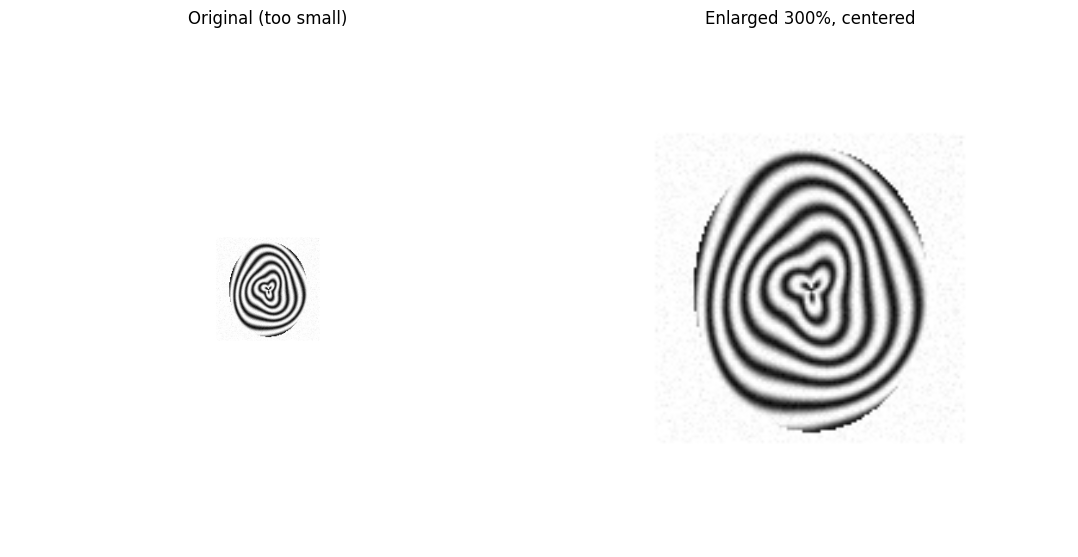

In [4]:
fp = load_rgb(paths['fingerprint'])
h, w = fp.shape[:2]
screen_w, screen_h = 600, 600            # the 'screen' we display on

# 2x2 scaling matrix: 300% on x and y
S = np.array([[3.0, 0.0],
              [0.0, 3.0]])

# Keep it centered:  center_out = S @ center_in + t   ->   t = center_out - S @ center_in
center_in  = np.array([w / 2, h / 2])
center_out = np.array([screen_w / 2, screen_h / 2])
t = center_out - S @ center_in

M = np.hstack([S, t.reshape(2, 1)])      # 2x3 matrix for warpAffine
print('Scaling matrix S:\n', S)
print('Translation t   :', t)
print('Full 2x3 matrix :\n', M)
print('Image center maps to:', S @ center_in + t, '(screen center =', center_out, ')')

# Original placed in the middle of the same screen, for a fair comparison
M_orig = np.hstack([np.eye(2), (center_out - center_in).reshape(2, 1)])
before = warp_affine(fp, M_orig, (screen_w, screen_h), border=(255, 255, 255))
after  = warp_affine(fp, M,      (screen_w, screen_h), border=(255, 255, 255))
show([before, after], ['Original (too small)', 'Enlarged 300%, centered'], figsize=(11, 5.5))

## Task 2: The Dizzy Satellite (Linear – Rotation)
The photo is tilted by +45° (clockwise), so we rotate by **−45°** using `R = [[cos θ, −sin θ], [sin θ, cos θ]]`.
To avoid chopping the corners, the new canvas must be `new_w = w·|cos θ| + h·|sin θ|` and `new_h = w·|sin θ| + h·|cos θ|`, and we shift so the image center lands on the new canvas center.

Rotation matrix:
 [[ 0.7071  0.7071]
 [-0.7071  0.7071]]
Old size: 566 x 566   ->   New size: 801 x 801


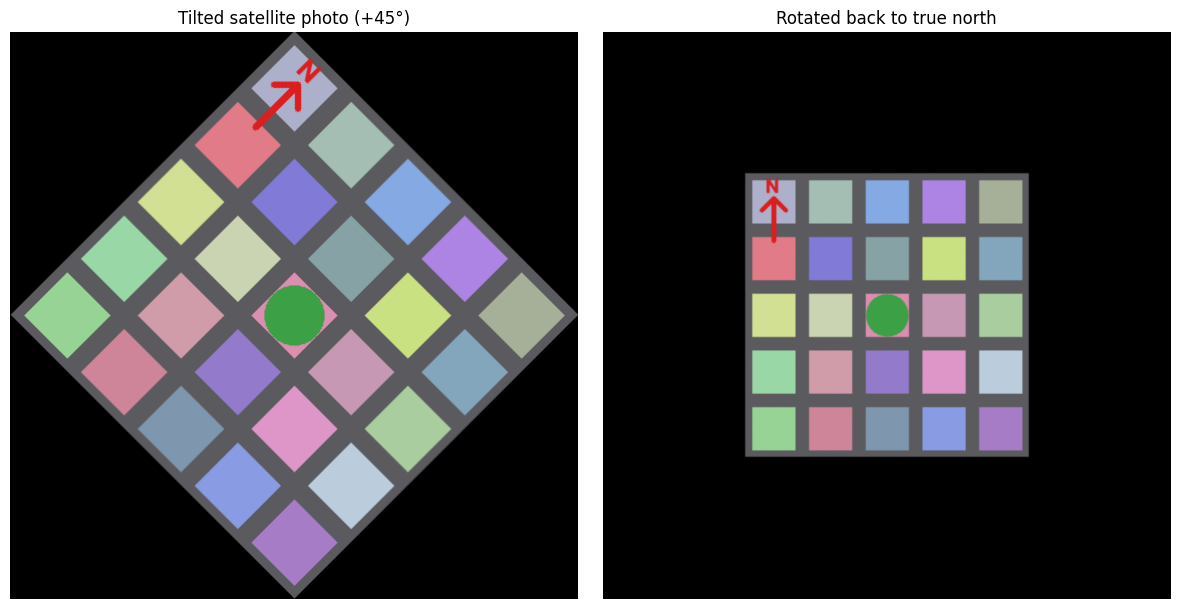

In [5]:
sat = load_rgb(paths['satellite'])
h, w = sat.shape[:2]

theta = -45                                   # undo the +45 degree tilt
a = np.deg2rad(theta)
R2 = np.array([[np.cos(a), -np.sin(a)],
               [np.sin(a),  np.cos(a)]])      # 2x2 rotation matrix (sine / cosine)
print('Rotation matrix:\n', np.round(R2, 4))

# Manually compute the new dimensions so nothing is cut off
new_w = int(np.ceil(w * abs(np.cos(a)) + h * abs(np.sin(a))))
new_h = int(np.ceil(w * abs(np.sin(a)) + h * abs(np.cos(a))))
print(f'Old size: {w} x {h}   ->   New size: {new_w} x {new_h}')

# rotate about the old center, then drop that center onto the new canvas center
t = np.array([new_w / 2, new_h / 2]) - R2 @ np.array([w / 2, h / 2])
M = np.hstack([R2, t.reshape(2, 1)])

fixed = warp_affine(sat, M, (new_w, new_h))
show([sat, fixed], ['Tilted satellite photo (+45°)', 'Rotated back to true north'], figsize=(12, 6))

## Task 3: The Fast Train Barcode (Linear – Shear)
The slant follows `x' = x + k·y`. We measure `k` from the first bar (how far its left edge moves between a top row and a bottom row), then undo it with the shear matrix `[[1, −k], [0, 1]]`.

Estimated shear factor k = 0.446
Shear matrix:
 [[ 1.         -0.44615385]
 [ 0.          1.        ]]


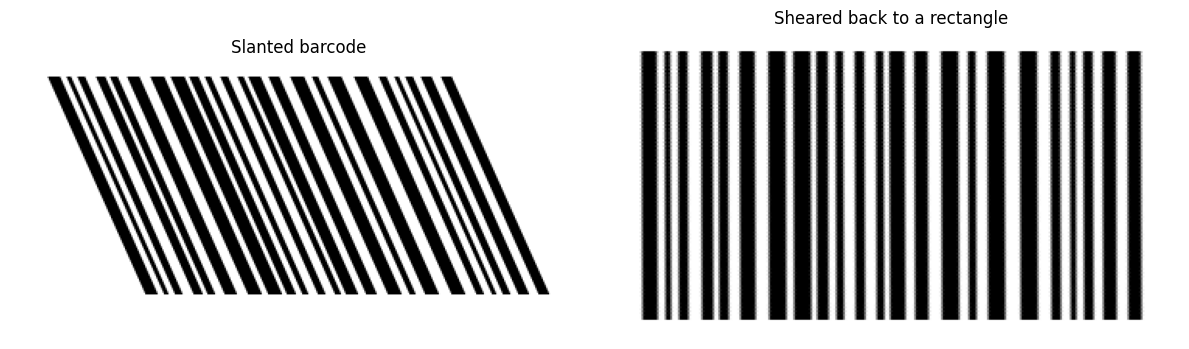

In [6]:
bar = load_rgb(paths['barcode_slanted'])
gray = cv2.cvtColor(bar, cv2.COLOR_RGB2GRAY)
H_img, W_img = gray.shape

# Estimate the slant: x-position of the first dark pixel in a top row and a bottom row
top_row, bot_row = 15, H_img - 15
x_top = np.argmax(gray[top_row] < 128)
x_bot = np.argmax(gray[bot_row] < 128)
k = (x_bot - x_top) / (bot_row - top_row)
print(f'Estimated shear factor k = {k:.3f}')

# 2x2 shear matrix that pushes pixels back to the LEFT, proportional to their height
shear = np.array([[1.0, -k],
                  [0.0, 1.0]])
print('Shear matrix:\n', shear)

M = np.hstack([shear, np.zeros((2, 1))])
fixed = warp_affine(bar, M, (W_img, H_img), border=(255, 255, 255))
fixed = fixed[:, : W_img - int(round(k * H_img))]      # crop the empty padding on the right
show([bar, fixed], ['Slanted barcode', 'Sheared back to a rectangle'], figsize=(12, 4))

## Task 4: The Hidden Treasure Map (Affine – Translation)
A 2x2 matrix cannot move anything, so we upgrade to **3x3 homogeneous matrices**: `[[1, 0, tx], [0, 1, ty], [0, 0, 1]]`.
The map is currently drawn 150 px left and 80 px up (`T_bad`), hiding the X off-screen. Sliding it **+150 px right and +80 px down** (`T_fix`) brings it back into the frame.

T_fix =
 [[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]]
X (before fix) on screen: [-60. -10.] -> off-screen!
X (after fix)  on screen: [90. 70.]


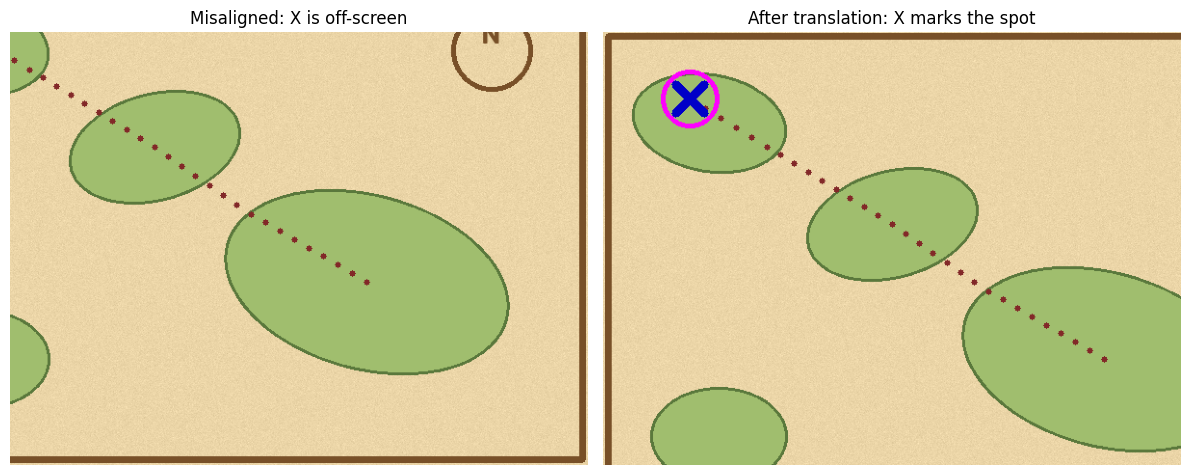

In [7]:
map_full = load_rgb(paths['treasure_map'])          # the complete map (the X is near its top-left)
screen_w, screen_h = 600, 450
X_map = np.array([[90, 70]])                        # where the X sits on the map (pixel coordinates)

T_bad = translation_matrix(-150, -80)               # current (misaligned) placement
T_fix = translation_matrix(+150, +80)               # the fix
print('T_fix =\n', T_fix)

# A single pixel as a homogeneous vector [x, y, 1]
print('X (before fix) on screen:', transform_points(T_bad, X_map)[0], '-> off-screen!')
print('X (after fix)  on screen:', transform_points(T_fix @ T_bad, X_map)[0])

before = warp_affine(map_full, T_bad, (screen_w, screen_h))
after  = warp_affine(map_full, T_fix @ T_bad, (screen_w, screen_h))     # every pixel shifted by T_fix
cv2.circle(after, tuple(int(v) for v in X_map[0]), 28, (255, 0, 255), 3)
show([before, after], ['Misaligned: X is off-screen', 'After translation: X marks the spot'], figsize=(12, 5))

## Task 5: The Robot's Assembly Line (Rigid Transformation)
A rigid transformation = rotation + translation (shape and size unchanged). We combine them into **one 3x3 matrix**:
`M = T(gripper_center) · R(−angle) · T(−chip_center)` – move the chip center to the origin, rotate it upright, then move it to the gripper.

Single 3x3 rigid matrix:
 [[ 2.58800e-01  9.65900e-01 -3.30783e+01]
 [-9.65900e-01  2.58800e-01  4.95085e+02]
 [ 0.00000e+00  0.00000e+00  1.00000e+00]]
Chip center maps to: [250. 250.]


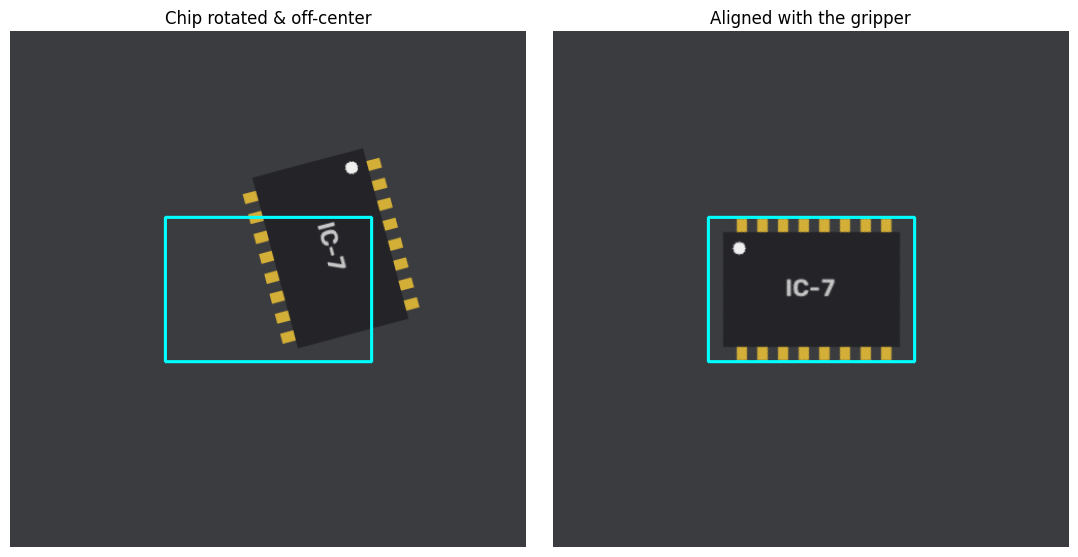

In [8]:
chip = load_rgb(paths['chip'])
BELT = (58, 60, 64)

chip_center    = (310, 210)       # measured: where the chip currently is
chip_angle     = 75               # measured: how far it is rotated (degrees, clockwise)
gripper_center = (250, 250)       # where the gripper expects the chip

M = (translation_matrix(*gripper_center)
     @ rotation_matrix(-chip_angle)
     @ translation_matrix(-chip_center[0], -chip_center[1]))
print('Single 3x3 rigid matrix:\n', np.round(M, 4))
print('Chip center maps to:', transform_points(M, [chip_center])[0])

aligned = warp_affine(chip, M, (chip.shape[1], chip.shape[0]), border=BELT)

def draw_gripper(img):
    out = img.copy()
    cv2.rectangle(out, (gripper_center[0] - 100, gripper_center[1] - 70),
                       (gripper_center[0] + 100, gripper_center[1] + 70), (0, 255, 255), 2)
    return out

show([draw_gripper(chip), draw_gripper(aligned)], ['Chip rotated & off-center', 'Aligned with the gripper'], figsize=(11, 5.5))

## Task 6: The Architect's Blueprint (Similarity Transformation)
Similarity = uniform **scale + rotation + translation** (angles preserved, size changes). One 3x3 matrix:
`M = T(target) · R(−25°) · S(2) · T(−current_center)`.

One similarity matrix:
 [[  1.8126   0.8452  12.9316]
 [ -0.8452   1.8126 192.3669]
 [  0.       0.       1.    ]]
Recovered scale : 2.0
Recovered angle : -25.0 degrees


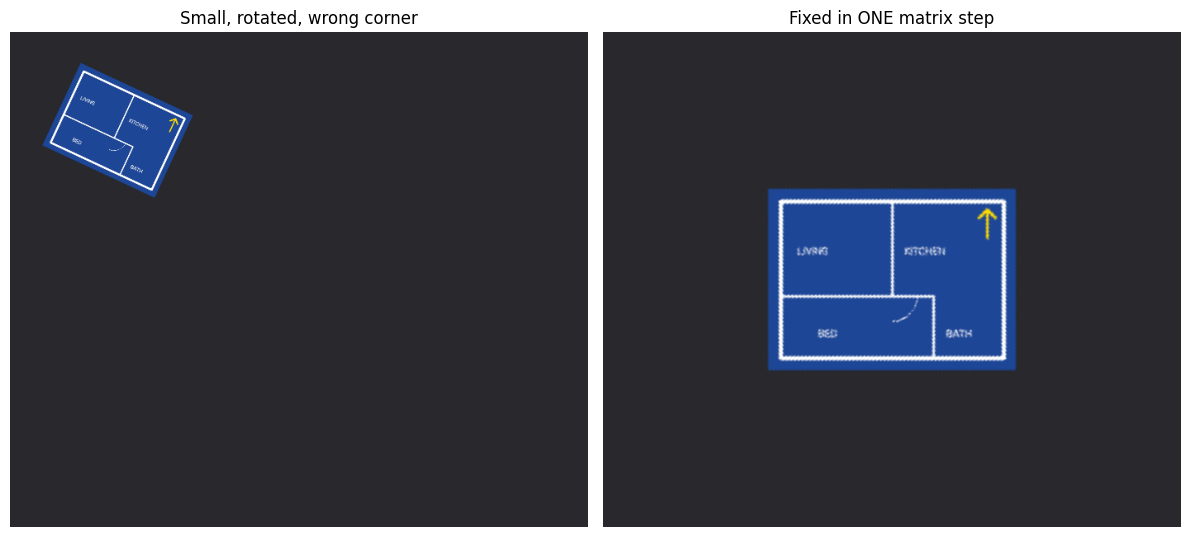

In [9]:
blueprint = load_rgb(paths['blueprint'])

current_center = (130, 120)       # where the small blueprint currently sits (wrong corner)
target_center  = (350, 300)       # where we want it (middle of the canvas)
scale_factor   = 2.0              # it is 50% too small
angle          = -25              # it was rotated +25 degrees

M = (translation_matrix(*target_center)
     @ rotation_matrix(angle)
     @ scale_matrix(scale_factor, scale_factor)
     @ translation_matrix(-current_center[0], -current_center[1]))
print('One similarity matrix:\n', np.round(M, 4))
print('Recovered scale :', round(float(np.hypot(M[0, 0], M[1, 0])), 3))
print('Recovered angle :', round(float(np.degrees(np.arctan2(M[1, 0], M[0, 0]))), 2), 'degrees')

fixed = warp_affine(blueprint, M, (700, 600), border=(40, 40, 45))
show([blueprint, fixed], ['Small, rotated, wrong corner', 'Fixed in ONE matrix step'], figsize=(12, 5.5))

## Task 7: The Glitched Image (General Affine)
A general affine map has **6 unknowns**: `x' = a·x + b·y + tx`, `y' = c·x + d·y + ty`.
Each landmark pair gives 2 equations, so 3 landmarks give a 6x6 linear system that we solve with `np.linalg.solve`. The fix is the inverse of the recovered matrix.

Recovered glitch matrix:
 [[ 6.5700e-01 -6.0000e-02  9.0451e+01]
 [ 2.4000e-01  1.0430e+00  3.9579e+01]
 [ 0.0000e+00  0.0000e+00  1.0000e+00]]
OpenCV check (max diff): 2.842170943040401e-14


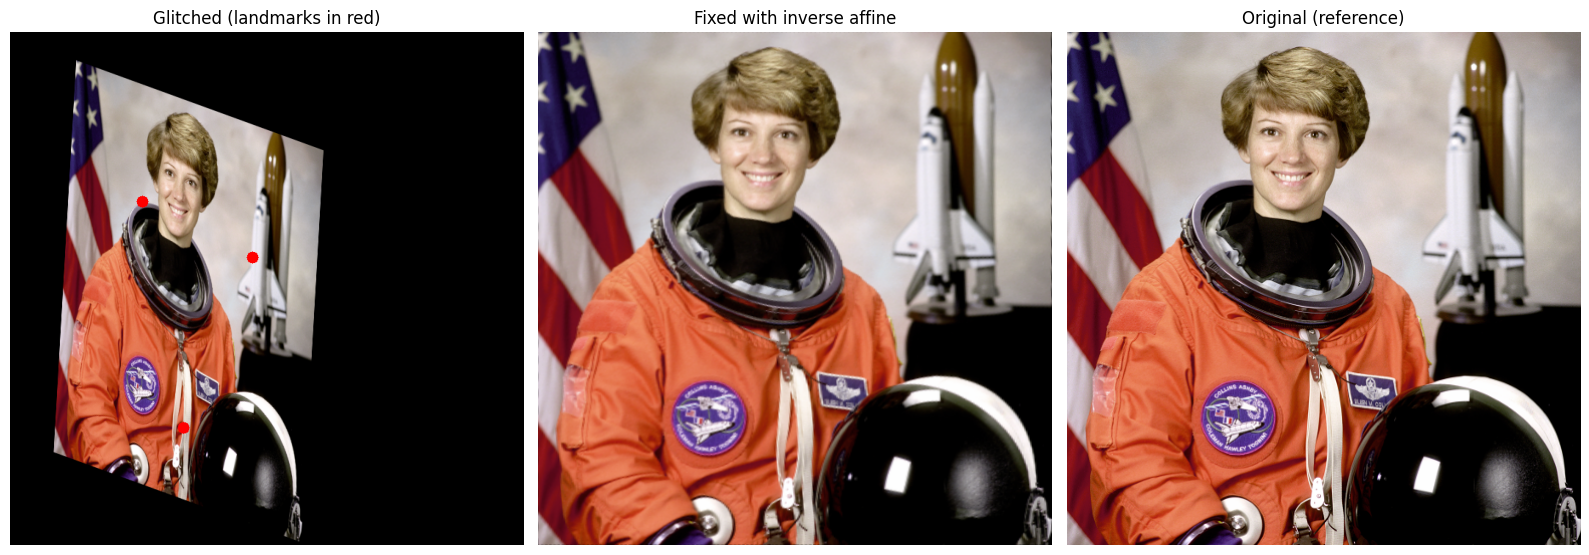

In [10]:
glitched = load_rgb(paths['glitched'])
original = load_rgb(paths['photo_original'])            # only used to compare at the end

# 3 landmarks: position in the ORIGINAL photo -> position in the GLITCHED photo
pts_start = np.float32([[150, 150], [380, 170], [260, 420]])
pts_end   = np.float32([[180, 232], [330, 308], [236, 540]])

# Build the 6x6 system  A @ [a, b, tx, c, d, ty] = rhs
A, rhs = [], []
for (x, y), (u, v) in zip(pts_start, pts_end):
    A.append([x, y, 1, 0, 0, 0]); rhs.append(u)
    A.append([0, 0, 0, x, y, 1]); rhs.append(v)
a, b, tx, c, d, ty = np.linalg.solve(np.array(A, float), np.array(rhs, float))

M_glitch = np.array([[a, b, tx],
                     [c, d, ty],
                     [0, 0, 1]])
print('Recovered glitch matrix:\n', np.round(M_glitch, 3))
print('OpenCV check (max diff):', np.abs(M_glitch[:2] - cv2.getAffineTransform(pts_start, pts_end)).max())

M_fix = np.linalg.inv(M_glitch)                         # undo the glitch
fixed = warp_affine(glitched, M_fix, (original.shape[1], original.shape[0]))

marked = glitched.copy()
for p in pts_end:
    cv2.circle(marked, tuple(int(v) for v in p), 8, (255, 0, 0), -1)
show([marked, fixed, original], ['Glitched (landmarks in red)', 'Fixed with inverse affine', 'Original (reference)'], figsize=(16, 5.5))

## Task 8: The Sidewalk Illusion (Projective – Perspective)
Pick the 4 corners of the art in the photo (they should form a square in real life) and map them to a perfect square. The 3x3 homography comes from an 8x8 linear system (`find_homography`); OpenCV's `getPerspectiveTransform` is used only as a check.

Homography matrix:
 [[ 7.58197000e+00  3.89344000e+00 -2.78278689e+03]
 [ 0.00000000e+00  1.22950800e+01 -1.84426230e+03]
 [ 0.00000000e+00  1.55700000e-02  1.00000000e+00]]
Max difference vs OpenCV: 9.094947017729282e-13


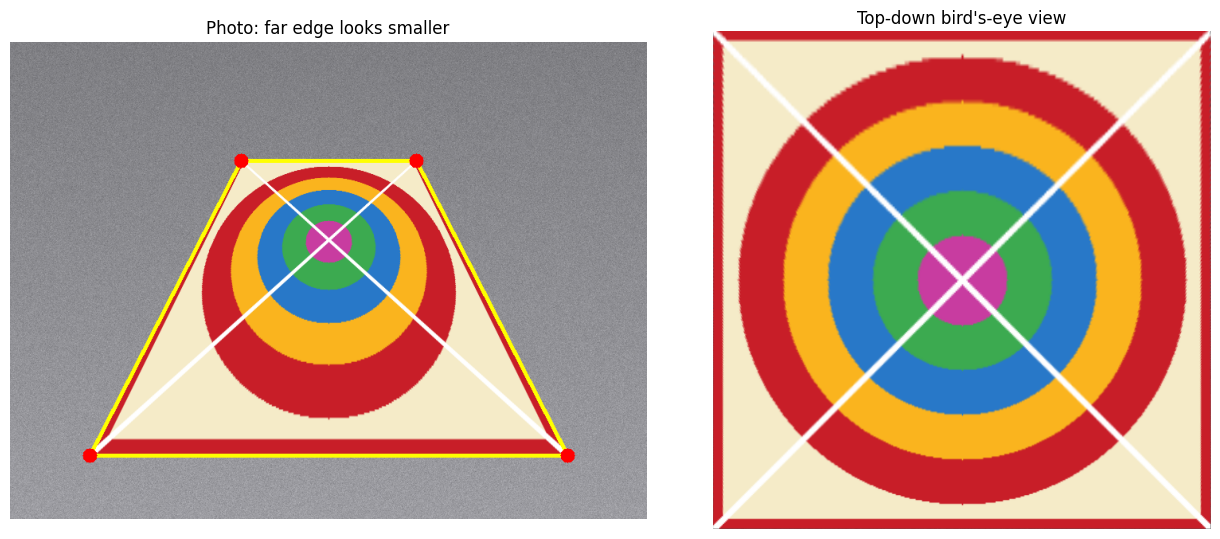

In [11]:
photo = load_rgb(paths['sidewalk'])

# 4 corners of the art in the photo (TL, TR, BR, BL) - the far edge (top) looks shorter
src = np.float32([[290, 150], [510, 150], [700, 520], [100, 520]])
side = 500
dst = np.float32([[0, 0], [side, 0], [side, side], [0, side]])      # a perfect square

H = find_homography(src, dst)
H_cv = cv2.getPerspectiveTransform(src, dst)
print('Homography matrix:\n', np.round(H, 5))
print('Max difference vs OpenCV:', np.abs(H - H_cv).max())

birdseye = warp_persp(photo, H, (side, side))

marked = photo.copy()
cv2.polylines(marked, [src.astype(np.int32)], True, (255, 255, 0), 3)
for p in src:
    cv2.circle(marked, tuple(int(v) for v in p), 9, (255, 0, 0), -1)
show([marked, birdseye], ['Photo: far edge looks smaller', "Top-down bird's-eye view"], figsize=(13, 5.5))

## Task 9: The Stadium Panorama (Projective – Homography)
Four cones are visible in **both** photos. Their positions give us `H` that maps camera 2 into camera 1's space. We then work out how big the combined canvas must be, warp camera 2 onto it, paste camera 1 and average the overlap.

Homography (cam2 -> cam1):
 [[ 1.190800e+00 -3.260000e-02  6.401056e+02]
 [ 3.070000e-02  1.067800e+00 -1.988410e+01]
 [ 1.000000e-04  0.000000e+00  1.000000e+00]]
Max difference vs OpenCV : 1.1368683772161603e-13
Panorama size: (1660, 641)


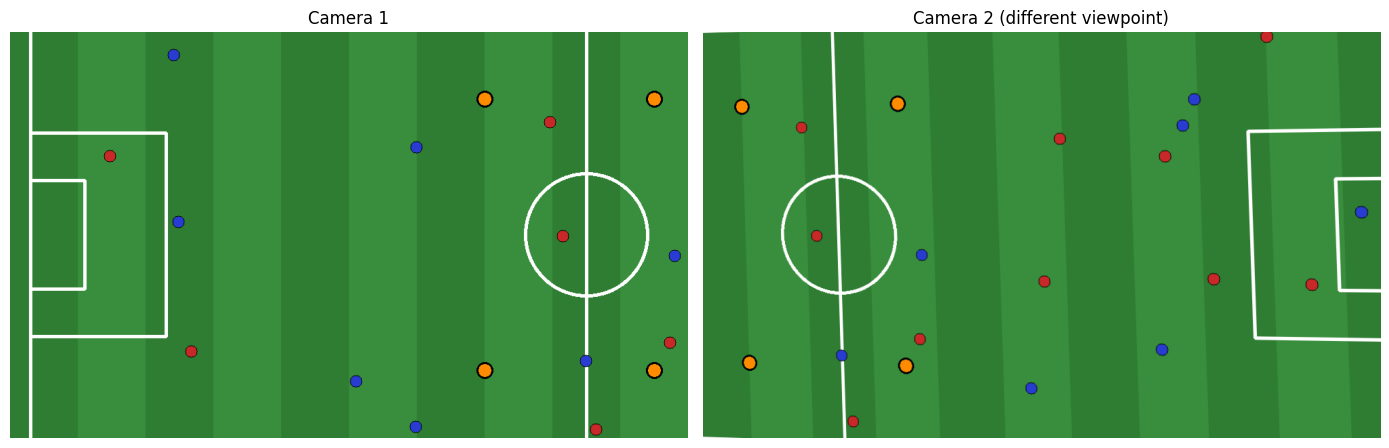

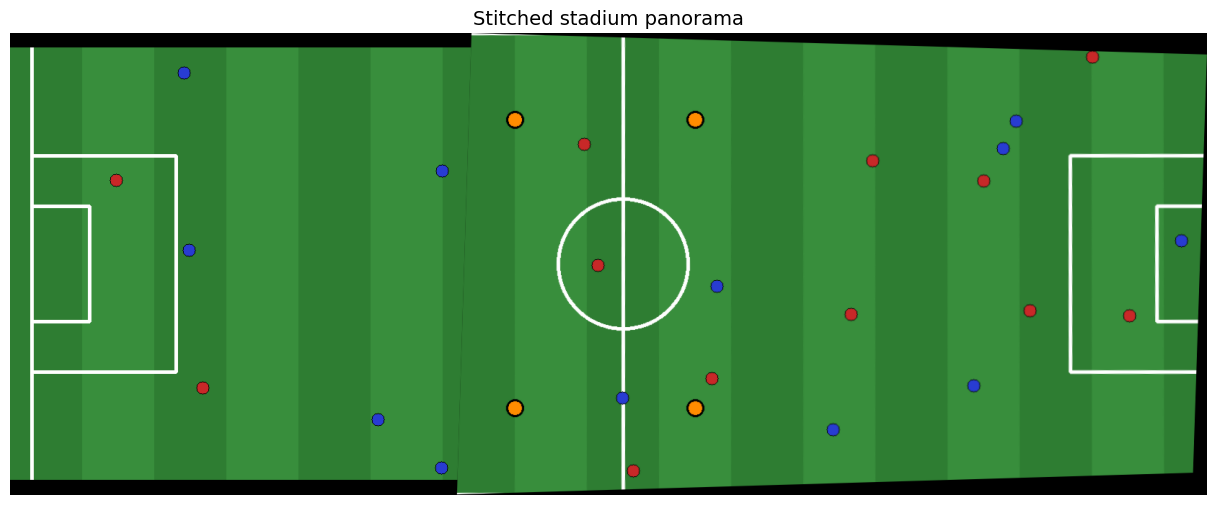

In [12]:
cam1 = load_rgb(paths['cam1'])
cam2 = load_rgb(paths['cam2'])

# The same 4 cones as seen in each camera (x, y)
pts_cam1 = np.float32([[700, 100], [950, 100], [950, 500], [700, 500]])
pts_cam2 = np.float32([[56.9, 111.2], [286.9, 106.8], [299.0, 493.1], [68.3, 488.6]])

H = find_homography(pts_cam2, pts_cam1)                 # camera 2  ->  camera 1 space
print('Homography (cam2 -> cam1):\n', np.round(H, 4))
print('Max difference vs OpenCV :', np.abs(H - cv2.getPerspectiveTransform(pts_cam2, pts_cam1)).max())

# Work out the canvas that holds BOTH images
h1, w1 = cam1.shape[:2]
h2, w2 = cam2.shape[:2]
corners1 = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]])
corners2 = transform_points(H, [[0, 0], [w2, 0], [w2, h2], [0, h2]])
all_pts = np.vstack([corners1, corners2])
xmin, ymin = np.floor(all_pts.min(axis=0)).astype(int)
xmax, ymax = np.ceil(all_pts.max(axis=0)).astype(int)
T = translation_matrix(-xmin, -ymin)                    # shift so nothing has negative coordinates
size = (int(xmax - xmin), int(ymax - ymin))
print('Panorama size:', size)

# Warp both images into the panorama (+ masks showing where each one has pixels)
c1 = warp_affine(cam1, T, size).astype(np.float32)
c2 = warp_persp(cam2, T @ H, size).astype(np.float32)
m1 = warp_affine(np.ones((h1, w1), np.float32), T, size)
m2 = warp_persp(np.ones((h2, w2), np.float32), T @ H, size)

# Weighted average: overlap is blended 50/50, elsewhere we use whichever image has pixels
weight = np.maximum(m1 + m2, 1e-6)[..., None]
pano = ((c1 * m1[..., None] + c2 * m2[..., None]) / weight).astype(np.uint8)

show([cam1, cam2], ['Camera 1', 'Camera 2 (different viewpoint)'], figsize=(14, 4.5))
plt.figure(figsize=(16, 6)); plt.imshow(pano); plt.axis('off'); plt.title('Stitched stadium panorama', fontsize=14); plt.show()

## Task 10: The Master Forger (Full Hierarchy Challenge)
1. **Linear** – scale the painting down (`S`).
2. **Rigid** – rotate and move it next to / onto the frame (`R`, `T`).
3. **Projective** – warp its 4 corners onto the 4 inner corners of the angled frame (`P`).

All three combine into one matrix: `M_total = P · Rigid · S`.

Scale matrix S:
 [[0.5 0.  0. ]
 [0.  0.5 0. ]
 [0.  0.  1. ]]
Rigid matrix:
 [[ 9.85000e-01 -1.74000e-01  3.54644e+02]
 [ 1.74000e-01  9.85000e-01  2.44222e+02]
 [ 0.00000e+00  0.00000e+00  1.00000e+00]]
Projective matrix P:
 [[ 2.8179200e+00  4.9687000e-01 -5.6454280e+02]
 [ 3.4140000e-02  3.4286900e+00 -5.6296196e+02]
 [ 1.7200000e-03  3.0000000e-04  1.0000000e+00]]
Painting corners now land on:
 [[330. 170.]
 [640. 215.]
 [640. 520.]
 [330. 570.]]


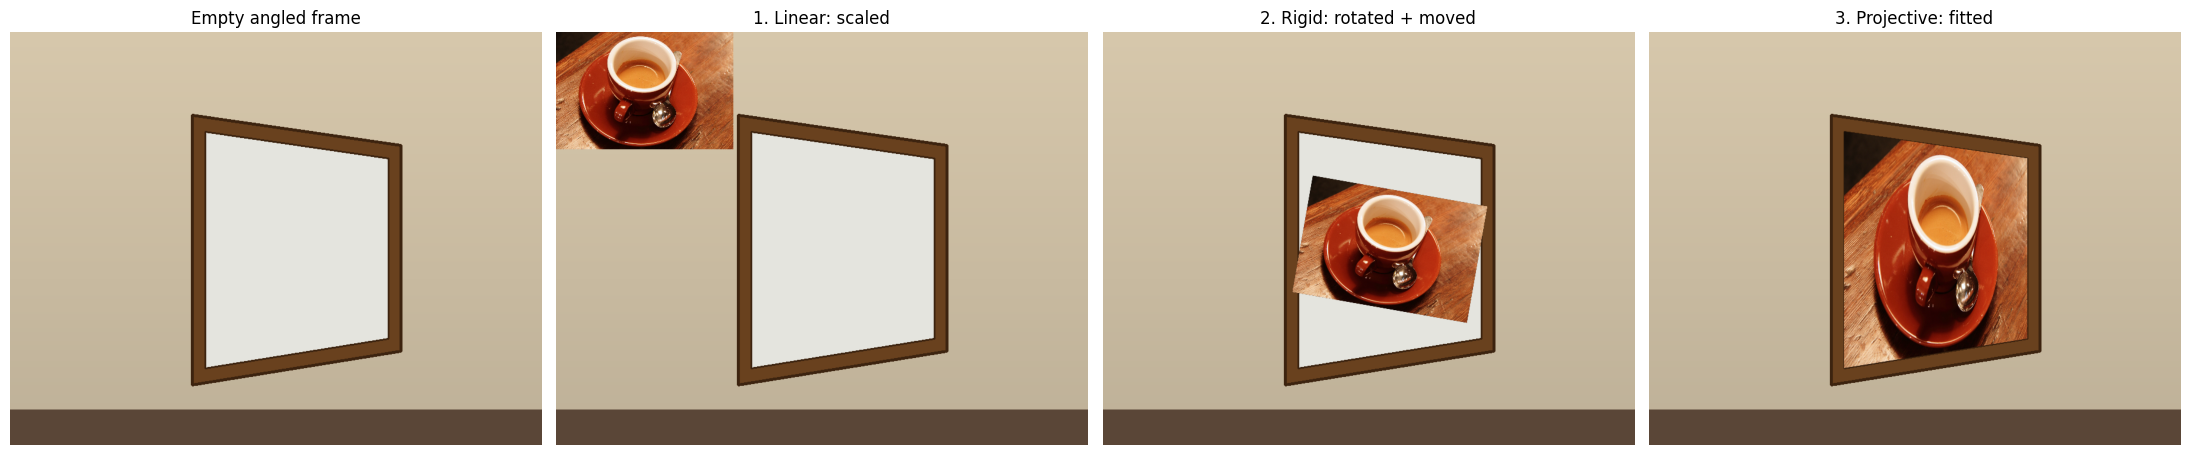

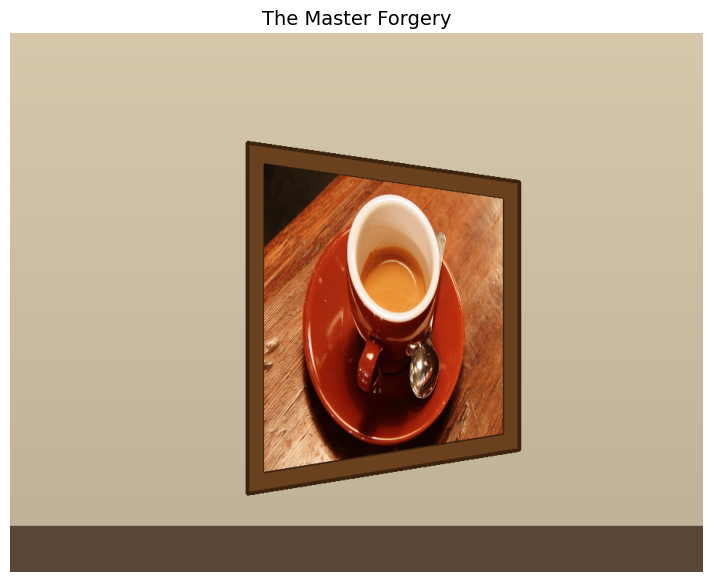

In [13]:
wall = load_rgb(paths['wall'])
painting = load_rgb(paths['painting'])
ph, pw = painting.shape[:2]

# Inner corners of the empty frame (TL, TR, BR, BL) - picked from the wall image
frame_inner = np.float32([[330, 170], [640, 215], [640, 520], [330, 570]])
corners = np.float32([[0, 0], [pw, 0], [pw, ph], [0, ph]])

def paste(scene, art, M):
    # warp `art` with matrix M and composite it onto `scene` using a warped mask
    size = (scene.shape[1], scene.shape[0])
    warped = warp_persp(art, M, size).astype(np.float32)
    alpha = warp_persp(np.full(art.shape[:2], 255, np.uint8), M, size).astype(np.float32)[..., None] / 255.0
    return (scene * (1 - alpha) + warped * alpha).astype(np.uint8)

# 1) LINEAR: shrink the painting to 50%
S = scale_matrix(0.5, 0.5)

# 2) RIGID: rotate 10 degrees and move its center onto the frame center
scaled_center = np.array([pw * 0.5 / 2, ph * 0.5 / 2])
frame_center = frame_inner.mean(axis=0)
Rigid = (translation_matrix(*frame_center)
         @ rotation_matrix(10)
         @ translation_matrix(*(-scaled_center)))
M_rigid = Rigid @ S

# 3) PROJECTIVE: map where the 4 corners are now onto the 4 frame corners
corners_now = transform_points(M_rigid, corners)
P = find_homography(corners_now, frame_inner)
M_total = P @ M_rigid                                   # the whole hierarchy in a single 3x3 matrix

print('Scale matrix S:\n', S)
print('Rigid matrix:\n', np.round(Rigid, 3))
print('Projective matrix P:\n', np.round(P, 5))
print('Painting corners now land on:\n', np.round(transform_points(M_total, corners), 1))

stage1 = paste(wall, painting, S)
stage2 = paste(wall, painting, M_rigid)
final  = paste(wall, painting, M_total)
show([wall, stage1, stage2, final],
     ['Empty angled frame', '1. Linear: scaled', '2. Rigid: rotated + moved', '3. Projective: fitted'], figsize=(22, 5))
plt.figure(figsize=(9, 7)); plt.imshow(final); plt.axis('off'); plt.title('The Master Forgery', fontsize=14); plt.show()